In [1]:
#%% Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
sns.set(style="whitegrid", palette="coolwarm", font_scale=1.1)
plt.rcParams['font.family'] = 'DejaVu Sans'

In [3]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [4]:
df.columns = (
    df.columns.str.strip()
            .str.lower()
            .str.replace(' ', '_')
            .str.replace('[^a-zA-Z0-9_]', '', regex=True)
)

In [5]:
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'size',
 'society',
 'total_sqft',
 'bath',
 'balcony',
 'price']

In [6]:
df.shape

(13320, 9)

In [7]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [8]:
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['size'] = df['size'].fillna(df['size'].mode()[0])

In [10]:
# Drop rows where price is missing (we can't predict without it)
df = df.dropna(subset=['price'])

In [11]:
df['bhk'] = df['size'].apply(lambda x: int(str(x).split(' ')[0]) if pd.notnull(x) else None)

In [12]:
# Convert 'total_sqft' column to numeric values
# This function handles ranges (e.g., "1000 - 1200")
def convert_sqft_to_num(x):
    try:
        if '-' in str(x):
            tokens = str(x).split('-')
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)


In [13]:
# Drop rows where sqft or bhk couldn't be cleaned
df = df.dropna(subset=['total_sqft', 'bhk'])

In [14]:
# 'size' is dropped because we created 'bhk'.
# 'availability' is dropped because it's not very useful for this model.
df = df.drop(columns=['size', 'society', 'availability'])
print("Created 'bhk' and cleaned 'total_sqft'.")
print("Dropped 'society', 'size', and 'availability'.")
df.shape

Created 'bhk' and cleaned 'total_sqft'.
Dropped 'society', 'size', and 'availability'.


(13274, 7)

In [15]:
# Remove properties with unrealistic sqft per BHK (<300)
# This is a good way to find and remove bad data
df = df[df['total_sqft'] / df['bhk'] >= 300]

In [16]:
Q1, Q3 = df['price'].quantile(0.25), df['price'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
df = df[(df['price'] >= lower) & (df['price'] <= upper)]
print("✅ Outliers handled.")
print(f"Shape after outlier removal: {df.shape}")

✅ Outliers handled.
Shape after outlier removal: (11250, 7)


In [17]:
# Group rare locations (≤10 occurrences) as "other"
# This stops our model from getting confused by 1000s of locations
location_stats = df['location'].value_counts()
rare_locations = location_stats[location_stats <= 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)


In [18]:
# Convert 'location' and 'area_type' to dummy variables (0s and 1s)
df = pd.get_dummies(df, columns=['location', 'area_type'], drop_first=True)
print("✅ Encoding completed.")
print(f"Final shape after encoding: {df.shape}")


✅ Encoding completed.
Final shape after encoding: (11250, 217)


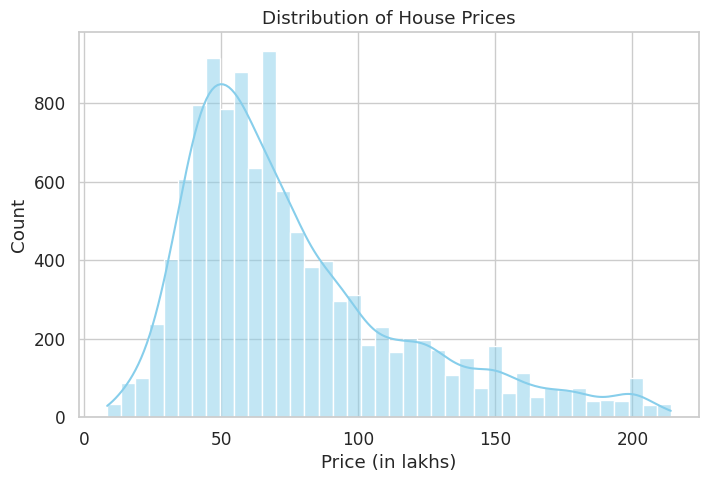

In [19]:
# Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40, kde=True, color='skyblue')
plt.title("Distribution of House Prices")
plt.xlabel("Price (in lakhs)")
plt.ylabel("Count")
plt.show()


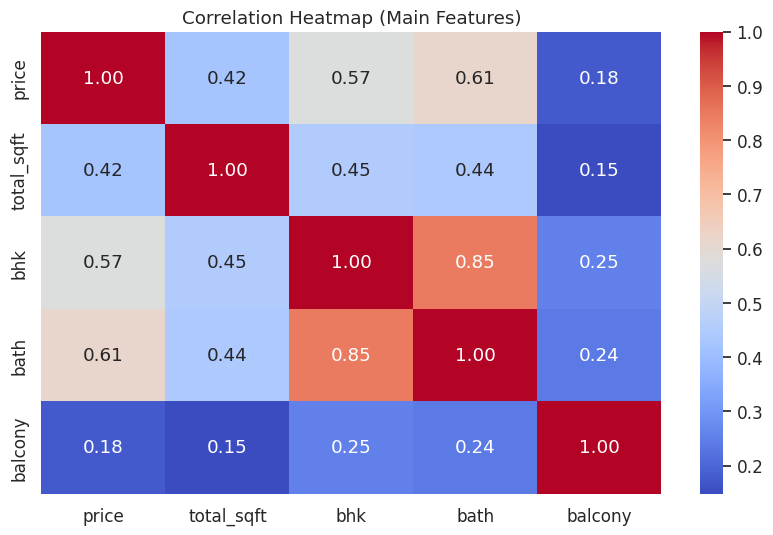

In [20]:
# Correlation heatmap
# We only check the main numeric features
numeric_features = ['price', 'total_sqft', 'bhk', 'bath', 'balcony']
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_features].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Main Features)")
plt.show()

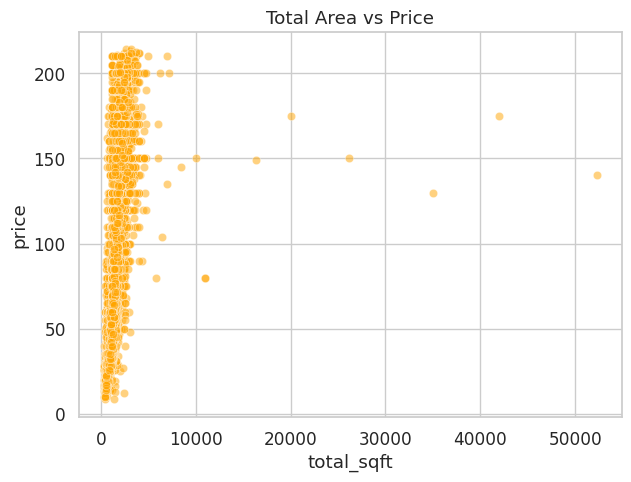

In [21]:
# Scatter: Total sqft vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x='total_sqft', y='price', data=df, color='orange', alpha=0.5)
plt.title("Total Area vs Price")
plt.show()

C:\Users\ishwa\AppData\Local\Temp\ipykernel_28716\338168592.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bhk', y='price', data=avg_price_bhk, palette='coolwarm')


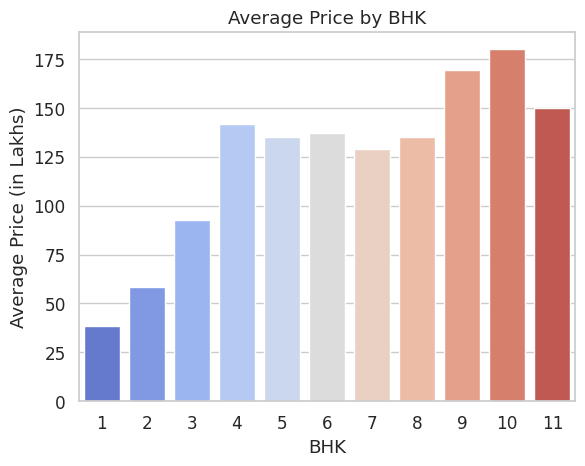

In [22]:
# Average price by BHK
avg_price_bhk = df.groupby('bhk')['price'].mean().reset_index()
sns.barplot(x='bhk', y='price', data=avg_price_bhk, palette='coolwarm')
plt.title("Average Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Average Price (in Lakhs)")
plt.show()

In [23]:
X = df.drop(columns=['price'], axis=1)

In [24]:
y = df['price']

In [25]:
X.shape

(11250, 216)

In [26]:
y.shape

(11250,)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
X_train.shape[0]

9000

In [32]:
X_test.shape[0]

2250

In [33]:
scaler = StandardScaler()

In [34]:
X_train_scaled = scaler.fit_transform(X_train)

In [35]:
X_test_scaled = scaler.transform(X_test)

In [36]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [37]:
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred) # Mean Squared Error (lower is better)
r2 = r2_score(y_test, y_pred)           # R-squared (higher is better)
print(f"📊 Mean Squared Error: {mse:.2f}")
print(f"📈 R² Score: {r2:.3f}")

📊 Mean Squared Error: 748.37
📈 R² Score: 0.540


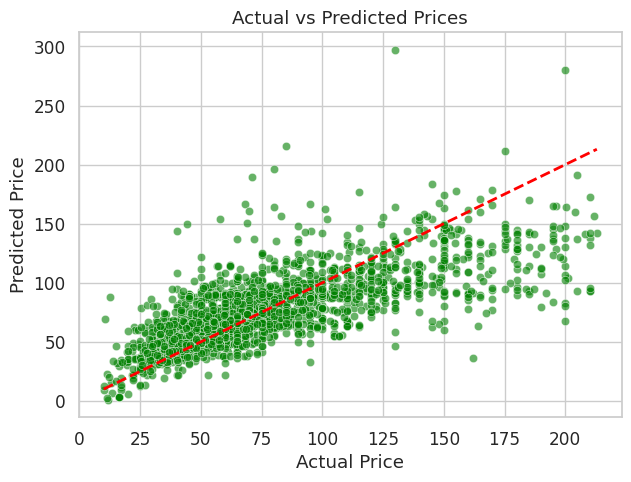

In [38]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred, color='green', alpha=0.6)
# This red line shows where a "perfect" prediction would be
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [ ]:
# Check which features the model thought were most important
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
# Get the absolute (positive) value to rank them
coeff_df = coeff_df.reindex(coeff_df.Coefficient.abs().sort_values(ascending=False).index)
print("Top 5 Most Influential Features on Price:")
print(coeff_df.head(5))

#export clean dataset
df.to_csv("Cleaned_RealEstate_Prices.csv", index=False)
